In [3]:
import warnings
import pandas as pd
# Suppress warnings
warnings.filterwarnings('ignore')

In [4]:
ec_data1 = pd.read_csv('Data//quinn_tenyears_pre_processed.csv').iloc[:,3:5]
ec_data1['building'] = 'Quinn_Business'
ec_data2 = pd.read_csv('Data//sutherland_tenyears.csv').iloc[:,4:6]
ec_data2['building'] = 'Sutherland_Law'
ec_data3 = pd.read_csv('Data//engg_clinton_tenyears.csv').iloc[:,3:5]
ec_data3['building'] = 'Engineering'
ec_data4 = pd.read_csv('Data//glenb9_tenyears.csv').iloc[:,4:6]
ec_data4['building'] = 'Glenomenab9'
ec_data5 = pd.read_csv('Data//ashfield_tenyears.csv').iloc[:,4:6]
ec_data5['building'] = 'Ashfield'
ec_data6 = pd.read_csv('Data//glenomenab10_tenyears.csv').iloc[:,3:5]
ec_data6['building'] = 'Glenomenab10'

In [5]:
ec_data1['timestamp'] = pd.to_datetime(ec_data1['timestamp'])
ec_data2['timestamp'] = pd.to_datetime(ec_data2['timestamp'])
ec_data3['timestamp'] = pd.to_datetime(ec_data3['timestamp'])
ec_data4['timestamp'] = pd.to_datetime(ec_data4['timestamp'])
ec_data5['timestamp'] = pd.to_datetime(ec_data5['timestamp'])
ec_data6['timestamp'] = pd.to_datetime(ec_data6['timestamp'])



ec_data = [ec_data1, ec_data2, ec_data3, ec_data4, ec_data5,ec_data6]

In [6]:
for df in ec_data:
    print(df)

        electric consumption           timestamp        building
0                  24.862499 2013-01-01 00:00:00  Quinn_Business
1                  24.779999 2013-01-01 00:15:00  Quinn_Business
2                  25.199999 2013-01-01 00:30:00  Quinn_Business
3                  25.514999 2013-01-01 00:45:00  Quinn_Business
4                  24.812500 2013-01-01 01:00:00  Quinn_Business
...                      ...                 ...             ...
297211             18.092499 2023-12-14 22:45:00  Quinn_Business
297212             15.132500 2023-12-14 23:00:00  Quinn_Business
297213             15.077499 2023-12-14 23:15:00  Quinn_Business
297214             14.832500 2023-12-14 23:30:00  Quinn_Business
297215             14.742499 2023-12-14 23:45:00  Quinn_Business

[297216 rows x 3 columns]
        electric consumption           timestamp        building
0                   5.200000 2013-11-29 00:00:00  Sutherland_Law
1                   5.515000 2013-11-29 00:15:00  Sutherland_La

In [7]:
import pandas as pd

# Assume ec_data is your list of DataFrames
hourly_data = []

for df in ec_data:
    # Make sure timestamp is datetime
    df['timestamp'] = pd.to_datetime(df['timestamp'])

    # Set timestamp as index for resampling
    df = df.set_index('timestamp')

    # Resample to hourly and sum consumption
    hourly = df.resample('H').sum()

    # Add building info back
    hourly['building'] = df['building'].iloc[0]

    # Reset index to get timestamp back as a column
    hourly = hourly.reset_index()

    # Append to list
    hourly_data.append(hourly)


In [8]:
all_buildings = pd.concat(hourly_data)
all_buildings

,timestamp,electric consumption,building
0,2013-01-01 00:00:00,100.357496,Quinn_Business
1,2013-01-01 01:00:00,100.169998,Quinn_Business
2,2013-01-01 02:00:00,101.797499,Quinn_Business
3,2013-01-01 03:00:00,102.809998,Quinn_Business
4,2013-01-01 04:00:00,101.722498,Quinn_Business
...,...,...,...
96403,2023-12-31 19:00:00,4.175000,Glenomenab10
96404,2023-12-31 20:00:00,4.605000,Glenomenab10
96405,2023-12-31 21:00:00,4.075000,Glenomenab10
96406,2023-12-31 22:00:00,4.125000,Glenomenab10


In [9]:
all_buildings

,timestamp,electric consumption,building
0,2013-01-01 00:00:00,100.357496,Quinn_Business
1,2013-01-01 01:00:00,100.169998,Quinn_Business
2,2013-01-01 02:00:00,101.797499,Quinn_Business
3,2013-01-01 03:00:00,102.809998,Quinn_Business
4,2013-01-01 04:00:00,101.722498,Quinn_Business
...,...,...,...
96403,2023-12-31 19:00:00,4.175000,Glenomenab10
96404,2023-12-31 20:00:00,4.605000,Glenomenab10
96405,2023-12-31 21:00:00,4.075000,Glenomenab10
96406,2023-12-31 22:00:00,4.125000,Glenomenab10


In [10]:
import pandas as pd

pivot_dfs = [] 

for df in hourly_data:
    
    weather_df = pd.read_csv('Data//merged_glen_weather.csv')

    weather_df = weather_df[['temp','timestamp','electric consumption']]

    # Convert timestamp columns to datetime format for accurate merging
    weather_df["timestamp"] = pd.to_datetime(weather_df["timestamp"])
    df["timestamp"] = pd.to_datetime(df["timestamp"])

    # Merge on timestamp
    merged_df = pd.merge(weather_df, df, on="timestamp", how="inner")

    df = merged_df
    
    # Pivot the data
    df['Date'] = pd.to_datetime(df['timestamp']).dt.date
    df['Time'] = pd.to_datetime(df['timestamp']).dt.time

    # Reshape using pivot
    pivot_df = df.pivot(index='Date', columns='Time', values='electric consumption_y')

    # Display the reshaped DataFrame
    pivot_df.reset_index(inplace=True) 
    
    pivot_df['building'] = merged_df['building']
    
    pivot_dfs.append(pivot_df)
    



In [11]:
all_buildings = pd.concat(pivot_dfs)
all_buildings

Time,Date,00:00:00,01:00:00,02:00:00,03:00:00,04:00:00,05:00:00,06:00:00,07:00:00,08:00:00,...,15:00:00,16:00:00,17:00:00,18:00:00,19:00:00,20:00:00,21:00:00,22:00:00,23:00:00,building
0,2013-01-01,100.357496,100.169998,101.797499,102.809998,101.722498,100.202497,104.159996,103.887497,96.312498,...,84.137497,90.487497,104.392498,101.934998,103.314997,105.424997,104.552498,103.152498,103.114998,Quinn_Business
1,2013-01-02,125.609999,126.367498,126.514996,130.022495,138.342503,137.564999,169.909996,187.169994,182.054996,...,176.962494,164.524998,176.397495,170.590000,170.059998,171.274994,166.894997,140.877499,124.359997,Quinn_Business
2,2013-01-03,117.769997,119.084997,116.949997,120.009998,128.644999,127.972498,165.200001,163.974995,168.145000,...,168.227497,155.524994,149.729996,150.782501,155.189999,153.277493,153.662495,130.604996,112.689999,Quinn_Business
3,2013-01-04,118.099998,119.114996,121.542500,131.604996,132.342499,134.224998,118.837498,117.587498,118.869997,...,117.519997,116.632496,116.657495,116.627497,131.634995,134.489998,121.159994,118.817497,119.044998,Quinn_Business
4,2013-01-05,61.417499,61.299998,61.559999,62.244999,58.522497,74.657499,94.830000,100.224997,107.152498,...,101.152498,89.099998,81.567499,82.717497,81.642500,95.817497,70.092498,59.557498,58.852499,Quinn_Business
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4012,2023-12-27,2.792500,2.670000,2.455000,2.555000,3.127500,3.105000,4.115000,4.365000,4.312500,...,3.425000,3.252500,3.267500,4.740000,4.587500,4.800000,5.070000,4.842500,3.935000,Glenomenab10
4013,2023-12-28,3.605000,3.402500,3.417500,3.352500,3.147500,3.145000,4.285000,4.345000,4.417500,...,3.532500,3.282500,3.440000,4.310000,4.390000,4.722500,4.652500,4.157500,3.222500,Glenomenab10
4014,2023-12-29,2.797500,3.315000,2.825000,2.637500,2.527500,2.545000,3.640000,3.867500,3.910000,...,2.520000,3.057500,2.700000,3.650000,4.052500,4.942500,4.555000,4.545000,3.410000,Glenomenab10
4015,2023-12-30,2.905000,2.685000,2.692500,2.602500,2.482500,2.420000,3.517500,3.687500,3.782500,...,2.565000,3.090000,3.060000,3.932500,4.315000,4.572500,4.095000,4.410000,3.152500,Glenomenab10


In [12]:
all_buildings['building'].value_counts()

building
Engineering       4017
Glenomenab9       4017
Glenomenab10      4017
Quinn_Business    4000
Sutherland_Law    3685
Ashfield          2649
Name: count, dtype: int64

In [14]:
df = all_buildings

In [15]:
# Filter the data based on start_date and end_date
start_date = '01-01-2017'
end_date = '01-01-2024'

df['Date'] = pd.to_datetime(df['Date'])

# Filter the DataFrame
df = df[(df['Date'] >= start_date) & (df['Date'] < end_date)]



In [16]:
# df.to_csv("all_buildings_final.csv")
df

Time,Date,00:00:00,01:00:00,02:00:00,03:00:00,04:00:00,05:00:00,06:00:00,07:00:00,08:00:00,...,15:00:00,16:00:00,17:00:00,18:00:00,19:00:00,20:00:00,21:00:00,22:00:00,23:00:00,building
1461,2017-01-01,55.052499,54.337499,55.692499,55.062499,55.797499,56.409998,59.402498,59.817499,57.177499,...,43.949999,51.682498,60.372499,60.897499,61.247499,59.339998,57.759997,57.372498,57.394999,Quinn_Business
1462,2017-01-02,63.994999,63.629999,63.280000,63.354998,62.687498,62.347498,104.647499,137.229996,149.982498,...,184.542496,182.969997,174.702496,158.549995,141.720001,135.144997,121.952497,81.327497,68.222498,Quinn_Business
1463,2017-01-03,64.374998,64.232499,63.772500,62.947498,63.327498,63.029999,121.797499,131.097498,157.632496,...,197.712494,202.074993,155.677498,156.204994,147.494999,133.484993,126.454998,75.009998,67.512497,Quinn_Business
1464,2017-01-04,63.584998,62.772498,63.017499,63.052499,62.329998,65.257498,52.902499,98.822498,124.277498,...,108.039997,101.167498,56.822498,49.552499,60.815000,66.202499,65.102500,63.394998,61.782498,Quinn_Business
1465,2017-01-05,67.287497,67.817497,66.439997,67.184999,66.874998,48.197498,48.387500,52.319999,50.839999,...,54.054999,50.757499,51.065000,51.280000,51.302499,65.674999,70.912497,70.372498,67.764999,Quinn_Business
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4012,2023-12-27,2.792500,2.670000,2.455000,2.555000,3.127500,3.105000,4.115000,4.365000,4.312500,...,3.425000,3.252500,3.267500,4.740000,4.587500,4.800000,5.070000,4.842500,3.935000,Glenomenab10
4013,2023-12-28,3.605000,3.402500,3.417500,3.352500,3.147500,3.145000,4.285000,4.345000,4.417500,...,3.532500,3.282500,3.440000,4.310000,4.390000,4.722500,4.652500,4.157500,3.222500,Glenomenab10
4014,2023-12-29,2.797500,3.315000,2.825000,2.637500,2.527500,2.545000,3.640000,3.867500,3.910000,...,2.520000,3.057500,2.700000,3.650000,4.052500,4.942500,4.555000,4.545000,3.410000,Glenomenab10
4015,2023-12-30,2.905000,2.685000,2.692500,2.602500,2.482500,2.420000,3.517500,3.687500,3.782500,...,2.565000,3.090000,3.060000,3.932500,4.315000,4.572500,4.095000,4.410000,3.152500,Glenomenab10


In [175]:
# df = pd.read_csv('all_buildings_final.csv').iloc[:,1:]

In [17]:
df.building.value_counts()

building
Sutherland_Law    2556
Engineering       2556
Glenomenab9       2556
Ashfield          2556
Glenomenab10      2556
Quinn_Business    2539
Name: count, dtype: int64

In [18]:
import pandas as pd

# Function to determine if a date is during term time (only for the year 2022)
def is_term_time(timestamp):
    # Extract month and day from the timestamp
    month = timestamp.month
    day = timestamp.day
    
    # Autumn Semester: September (9) to mid-December (12)
    # Spring Semester: January (1) to late April (4)
    if (month == 9) or (month == 10) or (month == 11) or \
       (month == 12 and day <= 15) or \
       (month == 1) or (month == 2) or (month == 3) or \
       (month == 4 and day <= 30):  # Assuming April has full term up to end of the month
        return 1  # During term time
    else:
        return 0  # Not during term time

def add_time_features(df):
    df['Date'] = pd.to_datetime(df['Date'])

    ### add in the month of the year (Jan - Dec)
    df['month'] = df['Date'].dt.month  # January=1, December=12

    ### add in the day of the week (Monday - Friday)
    df['DayOfWeek'] = df['Date'].dt.dayofweek  # Monday=0, Sunday=6

    ### add in the hour of the day
    df['hour'] = df['Date'].dt.hour 

    # Define seasons based on months
    season_mapping = {
        1: 1,  # Winter
        2: 1,  # Winter
        12: 1, # Winter
        3: 2,  # Spring
        4: 2,  # Spring
        5: 2,  # Spring
        6: 3,  # Summer
        7: 3,  # Summer
        8: 3,  # Summer
        9: 4,  # Autumn
        10: 4, # Autumn
        11: 4  # Autumn
    }

    ### add in the season of the year (1: Winter, 2: Spring, 3: Summer, 4: Autumn)
    df['season'] = df['month'].map(season_mapping)

    ### add in weekday/weekend
    df['weekday'] = df['DayOfWeek'].apply(lambda x: 0 if x >= 5 else 1)

    ### add in the time of term (teaching/non-teaching)
    df['term_time'] = df['Date'].apply(is_term_time)

    ### add in term_week column
    df['term_week'] = df.apply(lambda row: 1 if row['term_time'] == 1 and row['weekday'] == 1 else 0, axis=1)

    return df

time_df = add_time_features(df)

In [19]:
time_df

Time,Date,00:00:00,01:00:00,02:00:00,03:00:00,04:00:00,05:00:00,06:00:00,07:00:00,08:00:00,...,22:00:00,23:00:00,building,month,DayOfWeek,hour,season,weekday,term_time,term_week
1461,2017-01-01,55.052499,54.337499,55.692499,55.062499,55.797499,56.409998,59.402498,59.817499,57.177499,...,57.372498,57.394999,Quinn_Business,1,6,0,1,0,1,0
1462,2017-01-02,63.994999,63.629999,63.280000,63.354998,62.687498,62.347498,104.647499,137.229996,149.982498,...,81.327497,68.222498,Quinn_Business,1,0,0,1,1,1,1
1463,2017-01-03,64.374998,64.232499,63.772500,62.947498,63.327498,63.029999,121.797499,131.097498,157.632496,...,75.009998,67.512497,Quinn_Business,1,1,0,1,1,1,1
1464,2017-01-04,63.584998,62.772498,63.017499,63.052499,62.329998,65.257498,52.902499,98.822498,124.277498,...,63.394998,61.782498,Quinn_Business,1,2,0,1,1,1,1
1465,2017-01-05,67.287497,67.817497,66.439997,67.184999,66.874998,48.197498,48.387500,52.319999,50.839999,...,70.372498,67.764999,Quinn_Business,1,3,0,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4012,2023-12-27,2.792500,2.670000,2.455000,2.555000,3.127500,3.105000,4.115000,4.365000,4.312500,...,4.842500,3.935000,Glenomenab10,12,2,0,1,1,0,0
4013,2023-12-28,3.605000,3.402500,3.417500,3.352500,3.147500,3.145000,4.285000,4.345000,4.417500,...,4.157500,3.222500,Glenomenab10,12,3,0,1,1,0,0
4014,2023-12-29,2.797500,3.315000,2.825000,2.637500,2.527500,2.545000,3.640000,3.867500,3.910000,...,4.545000,3.410000,Glenomenab10,12,4,0,1,1,0,0
4015,2023-12-30,2.905000,2.685000,2.692500,2.602500,2.482500,2.420000,3.517500,3.687500,3.782500,...,4.410000,3.152500,Glenomenab10,12,5,0,1,0,0,0


In [20]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Ensure 'Date' is a datetime object
df['Date'] = pd.to_datetime(time_df['Date'])

# Extract day of the week (Monday = 0, ..., Sunday = 6)
df['DayOfWeek'] = time_df['Date'].dt.dayofweek

# Define working days (Monday to Friday) and holidays (Weekends: Saturday, Sunday)
df['IsHoliday'] = time_df['term_week']  # Make sure time_df is aligned properly

df = df[~df['Date'].dt.year.isin([2020, 2021])]

# Stratified sampling to maintain ratio of working days to holidays
train_df, test_df = train_test_split(
    df, test_size=0.3, random_state=42, stratify=df[['IsHoliday','building']]
)

# Reset index
train_df.reset_index(drop=True, inplace=True)
test_df.reset_index(drop=True, inplace=True)

# Create copies before scaling
train_df_scaled = train_df.copy()
test_df_scaled = test_df.copy()

# Select numerical columns to scale
numerical_cols = train_df.columns[1:25]  # adjust if column selection changes

# Initialize the scaler
scaler = StandardScaler()

# Fit and transform the training data
train_df_scaled[numerical_cols] = scaler.fit_transform(train_df_scaled[numerical_cols])

# Transform the test data using the same scaler
test_df_scaled[numerical_cols] = scaler.transform(test_df_scaled[numerical_cols])

# Display results
print("Train DataFrame shape:", train_df.shape)
print("Test DataFrame shape:", test_df.shape)
print("Train holiday ratio:", train_df['IsHoliday'].mean())
print("Test holiday ratio:", test_df['IsHoliday'].mean())

# Optionally, display a sample
print("\nSample of normalized Train DataFrame:")
print(train_df_scaled.head())


Train DataFrame shape: (7653, 34)
Test DataFrame shape: (3280, 34)
Train holiday ratio: 0.44165686658826603
Test holiday ratio: 0.44176829268292683

Sample of normalized Train DataFrame:
Time       Date  00:00:00  01:00:00  02:00:00  03:00:00  04:00:00  05:00:00  \
0    2023-12-11 -0.535432 -0.346512 -0.328583 -0.379115 -0.449643 -0.390967   
1    2019-09-05  0.964071  1.034609  1.036171  1.000543  1.011612  1.316679   
2    2023-10-10  0.283168  0.188016 -0.088629 -0.118644 -0.172064 -0.214000   
3    2022-05-20 -0.509783 -0.430841 -0.414236 -0.329405 -0.350426 -0.396212   
4    2019-09-10  1.786842  1.882328  1.866140  1.840470  1.873885  1.671454   

Time  06:00:00  07:00:00  08:00:00  ...  23:00:00        building  month  \
0    -0.318162 -0.193641 -0.100489  ... -0.608417  Sutherland_Law     12   
1     1.861210  1.575435  1.413872  ...  0.760296  Quinn_Business      9   
2    -0.179858 -0.107111 -0.093153  ...  0.750006        Ashfield     10   
3    -0.624367 -0.676698 -0.535560

In [21]:
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt
import numpy as np
import math

def gmm_clustering_and_plot(df_scaled, df, n_clusters=5):
    """
    Applies GMM clustering on scaled data and plots original unscaled time-series data by cluster.

    Parameters:
        df_scaled (DataFrame): Scaled DataFrame used
        for clustering.
        df (DataFrame): Original (unscaled) DataFrame used for plotting.
        n_clusters (int): Number of GMM clusters.

    Returns:
        df (DataFrame): Original DataFrame with added 'Cluster' column.
        gmm (GaussianMixture): Trained GMM model.
        bic_score (float): BIC score of the model.
    """
    # Time-series columns assumed to be from column 1 to 24 (e.g., hourly values)
    time_series_scaled = df_scaled.iloc[:, 1:25]

    # Fit Gaussian Mixture Model
    gmm = GaussianMixture(n_components=n_clusters, random_state=42)
    gmm_labels = gmm.fit_predict(time_series_scaled)
    bic_score = gmm.bic(time_series_scaled)

    # Add cluster labels to original DataFrame
    df['Cluster'] = gmm_labels

    # Plotting the unscaled data grouped by cluster
    n_rows = math.ceil(math.sqrt(n_clusters))
    n_cols = math.ceil(n_clusters / n_rows)

    plt.figure(figsize=(n_cols * 5, n_rows * 4))
    time_columns = df.columns[1:25]  # Adjust if necessary

    for cluster in range(n_clusters):
        cluster_df = df[df['Cluster'] == cluster]
        cluster_data = cluster_df[time_columns].values
        cluster_avg = cluster_data.mean(axis=0)

        plt.subplot(n_rows, n_cols, cluster + 1)
        for ts in cluster_data:
            plt.plot(ts, color='gray', alpha=0.5)

        plt.plot(cluster_avg, color='blue', linewidth=3, label='Reference Load Profile')
        plt.title(f"Cluster {cluster + 1} (N={len(cluster_df)})")
        plt.xlabel("Time Interval (1 hour)")
        plt.ylabel("Electric Consumption (kWh)")
        plt.grid(True)
        plt.legend()

    plt.suptitle(f"GMM Clustering on Scaled Data - Visualized on Original Data\nBIC Score: {bic_score:.2f}", fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

    print(f"BIC Score for {n_clusters} clusters: {bic_score:.2f}")

    return df, gmm, bic_score


In [22]:
train_df

Time,Date,00:00:00,01:00:00,02:00:00,03:00:00,04:00:00,05:00:00,06:00:00,07:00:00,08:00:00,...,23:00:00,building,month,DayOfWeek,hour,season,weekday,term_time,term_week,IsHoliday
0,2023-12-11,20.980000,26.020000,25.522500,22.952499,19.492499,23.502499,31.597499,45.197499,57.252499,...,21.017499,Sutherland_Law,12,0,0,1,1,1,1,1
1,2019-09-05,74.912498,75.112497,74.079998,72.702497,72.674997,89.505000,129.217501,138.527496,147.562496,...,76.552500,Quinn_Business,9,3,0,4,1,1,1,1
2,2023-10-10,50.422499,45.019999,34.059999,32.344999,29.594999,30.342499,37.792499,49.762499,57.689999,...,76.134999,Ashfield,10,1,0,4,1,1,1,1
3,2022-05-20,21.902499,23.022499,22.475000,24.745000,23.103515,23.299765,17.881719,19.713164,31.306718,...,22.639999,Ashfield,5,4,0,2,1,0,0,0
4,2019-09-10,104.504997,105.244997,103.609999,102.989996,104.057499,103.217495,119.932503,151.062496,169.409992,...,107.667496,Engineering,9,1,0,4,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7648,2019-03-19,5.680000,5.137500,4.775000,4.395000,4.040000,4.412500,6.437500,6.697500,10.360000,...,6.677500,Glenomenab9,3,1,0,2,1,1,1,1
7649,2019-08-03,20.379999,20.455000,20.845000,20.514999,19.760000,16.869999,17.722499,22.662500,23.885000,...,20.835000,Sutherland_Law,8,5,0,3,0,0,0,0
7650,2022-02-09,8.065000,6.430000,5.572500,5.025000,4.725000,5.132500,5.825000,7.995000,7.870000,...,9.215000,Glenomenab9,2,2,0,1,1,1,1,1
7651,2018-03-13,45.262499,39.069999,29.297499,25.169999,23.265000,19.292500,22.041054,28.773984,26.858359,...,110.644998,Ashfield,3,1,0,2,1,1,1,1


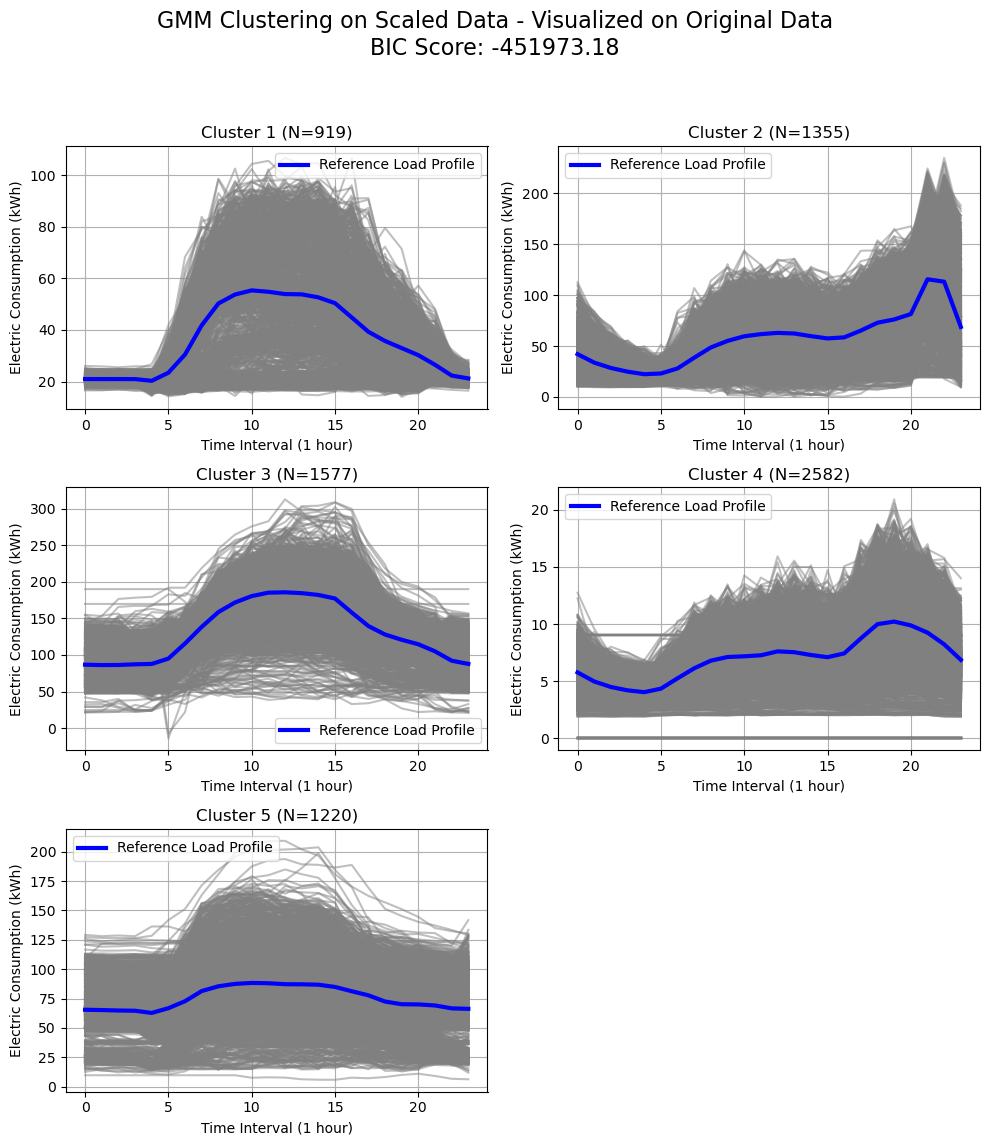

BIC Score for 5 clusters: -451973.18


In [23]:
clustered_df, model, bic  = gmm_clustering_and_plot(train_df_scaled, train_df, n_clusters=5)

In [24]:
clustered_df[clustered_df.Cluster==0].term_week.value_counts()

term_week
0    503
1    416
Name: count, dtype: int64

In [25]:
clustered_df[clustered_df.Cluster==1].building.value_counts()

building
Ashfield          1270
Sutherland_Law      85
Name: count, dtype: int64

In [26]:
clustered_df[clustered_df.Cluster==2].building.value_counts()

building
Engineering       899
Quinn_Business    668
Sutherland_Law     10
Name: count, dtype: int64

In [27]:
clustered_df[clustered_df.Cluster==3].building.value_counts()

building
Glenomenab9       1277
Glenomenab10      1277
Quinn_Business      25
Engineering          2
Ashfield             1
Name: count, dtype: int64

In [28]:
clustered_df[clustered_df.Cluster==4].building.value_counts()

building
Quinn_Business    573
Engineering       377
Sutherland_Law    263
Ashfield            6
Glenomenab9         1
Name: count, dtype: int64

In [29]:

#using the trained GMM model to predict the cluster labels in the test data

y_test_pred = model.predict(test_df_scaled.iloc[:,1:25])
# y_train

In [30]:
test_df['Cluster'] = y_test_pred
clustered_df_test = test_df

In [31]:
clustered_df_test

Time,Date,00:00:00,01:00:00,02:00:00,03:00:00,04:00:00,05:00:00,06:00:00,07:00:00,08:00:00,...,building,month,DayOfWeek,hour,season,weekday,term_time,term_week,IsHoliday,Cluster
0,2022-01-17,7.560000,6.310000,5.625000,5.285000,5.150000,5.252500,5.985000,6.907500,7.987500,...,Glenomenab10,1,0,0,1,1,1,1,1,3
1,2019-05-11,21.309999,21.052500,21.047500,21.057499,18.715000,17.362500,20.137500,26.947499,35.327500,...,Sutherland_Law,5,5,0,2,0,0,0,0,0
2,2023-05-15,19.875000,19.984999,19.977500,20.940000,17.970000,30.994999,41.120000,47.524999,51.172499,...,Sutherland_Law,5,0,0,2,1,0,0,0,0
3,2017-07-17,88.567497,88.162498,112.150000,111.649998,115.280001,129.769997,135.507492,157.814995,172.960003,...,Engineering,7,0,0,3,1,0,0,0,2
4,2019-06-03,5.475000,4.907500,4.750000,4.427500,4.670000,4.852500,4.937500,6.520000,5.352500,...,Glenomenab9,6,0,0,3,1,0,0,0,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3275,2023-12-27,69.922501,69.365000,69.264999,70.454998,69.754999,69.414999,69.979998,81.122499,81.744999,...,Engineering,12,2,0,1,1,0,0,0,4
3276,2019-05-16,97.584997,97.807499,97.357496,121.240000,126.129997,139.289997,127.542494,139.269997,154.492500,...,Engineering,5,3,0,2,1,0,0,0,2
3277,2019-01-12,106.455000,104.422499,102.697496,102.087498,102.179995,102.527494,102.422501,102.309998,107.077496,...,Engineering,1,5,0,1,0,1,0,0,2
3278,2017-10-31,67.257500,66.704998,66.817499,66.035000,65.764997,66.429998,109.002499,128.379997,147.174995,...,Quinn_Business,10,1,0,4,1,1,1,1,2


In [32]:
#storing the probability of being in a cluster for each DLP
probabilities = pd.DataFrame(model.predict_proba(train_df_scaled.iloc[:,1:25]))

In [33]:
prob_df = probabilities.round(3)

In [34]:
prob_df

,0,1,2,3,4
0,0.0,0.0,0.000,0.0,1.000
1,0.0,0.0,0.292,0.0,0.708
2,0.0,1.0,0.000,0.0,0.000
3,0.0,1.0,0.000,0.0,0.000
4,0.0,0.0,1.000,0.0,0.000
...,...,...,...,...,...
7648,0.0,0.0,0.000,1.0,0.000
7649,1.0,0.0,0.000,0.0,0.000
7650,0.0,0.0,0.000,1.0,0.000
7651,0.0,1.0,0.000,0.0,0.000


In [35]:
clustered_df['prob_1'] = prob_df[0]
clustered_df['prob_2'] = prob_df[1]
clustered_df['prob_3'] = prob_df[2]
clustered_df['prob_4'] = prob_df[3]
clustered_df['prob_5'] = prob_df[4]


In [40]:
building_map = {
    'Quinn_Business': 1,
    'Glenomenab9': 2,
    'Glenomenab10': 3,
    'Sutherland_Law': 4,
    'Ashfield': 5,
    'Engineering': 6
}

clustered_df['building_code'] = clustered_df['building'].map(building_map)
clustered_df_test['building_code'] = clustered_df_test['building'].map(building_map)

clustered_df.to_csv("all_buildings_clustered_scaled.csv")

In [138]:
from sklearn.metrics import silhouette_score, silhouette_samples

def calculate_silhouette(df_long):
    """
    Calculate the silhouette score for the clusters in the DataFrame.

    Parameters:
        df_long (DataFrame): DataFrame containing time-series data and cluster labels.
                             Assumes columns [hour, date, ...time-series values..., Cluster].
    
    Returns:
        overall_score (float): The overall silhouette score for the clustering.
        sample_scores (ndarray): Silhouette scores for each sample in the DataFrame.
    """
    # Extract time-series data and cluster labels
    time_series_columns = df_long.columns[1:25]  # Exclude 'hour', 'date', and 'Cluster'
    features = df_long[time_series_columns].values
    labels = df_long['Cluster'].values

    # Compute overall silhouette score
    overall_score = silhouette_score(features, labels)

    # Compute silhouette score for each sample
    sample_scores = silhouette_samples(features, labels)

    return overall_score, sample_scores

# Example usage:
overall_score, sample_scores = calculate_silhouette(train_df)
print(f"Overall Silhouette Score: {overall_score}")


Overall Silhouette Score: 0.43277636712675815


In [37]:
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
import numpy as np

def evaluate_gmm_clusters(df_long, min_clusters=2, max_clusters=20):
    """
    Evaluates Gaussian Mixture Models for different cluster sizes and computes AIC, BIC, and Silhouette Score.

    Parameters:
        df_long (DataFrame): Time-series data in long format.
                             Assumes time-series values start from column index 1 onward.
        min_clusters (int): Minimum number of clusters to test.
        max_clusters (int): Maximum number of clusters to test.

    Returns:
        results (dict): Dictionary containing AIC, BIC, and Silhouette Scores for each cluster count.
        optimal_clusters (int): Best cluster count based on the lowest BIC score.
    """
    time_series_data = df_long.iloc[:, 1:25]  # Extract time-series columns
    
    results = {"n_clusters": [], "AIC": [], "BIC": [], "Silhouette": []}
    
    best_bic = float("inf")
    optimal_clusters = min_clusters

    for n_clusters in range(min_clusters, max_clusters + 1):
        gmm = GaussianMixture(n_components=n_clusters, random_state=42)
        cluster_labels = gmm.fit_predict(time_series_data)

        # Compute metrics
        aic = gmm.aic(time_series_data)
        bic = gmm.bic(time_series_data)
        silhouette = silhouette_score(time_series_data, cluster_labels) if n_clusters > 1 else np.nan  # Silhouette needs at least 2 clusters

        # Store results
        results["n_clusters"].append(n_clusters)
        results["AIC"].append(aic)
        results["BIC"].append(bic)
        results["Silhouette"].append(silhouette)

        # Track best BIC
        if bic < best_bic:
            best_bic = bic
            optimal_clusters = n_clusters

    return results, optimal_clusters

# Example usage:
results, optimal_clusters = evaluate_gmm_clusters(train_df_scaled)
print(f"Optimal number of clusters (based on BIC): {optimal_clusters}")
print(results)


Optimal number of clusters (based on BIC): 13
{'n_clusters': [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20], 'AIC': [-369586.3146102985, -409372.01618733373, -445205.6736126228, -458535.9131509805, -469572.54505689745, -475146.0148915255, -480003.75842905324, -483741.09110840544, -486199.7585499305, -490549.59656170034, -491282.39190287405, -495766.02440492343, -497429.25001562963, -498430.6088336191, -501205.3975027666, -504242.5590902088, -504521.8924289055, -503750.0143739199, -505454.18429493054], 'BIC': [-365085.5112603591, -402617.34367140004, -436197.1319306948, -447273.50230305817, -456056.26504298084, -459375.8657116146, -461979.74008314806, -463463.2035965059, -463668.0018720367, -465763.97071781225, -464242.8968929917, -466472.6602290467, -465882.0166737586, -464629.5063257538, -465150.42582890694, -465933.71825035487, -463959.1824230573, -460933.43520207744, -460383.7359570937], 'Silhouette': [0.4032408998107468, 0.3659711691502022, 0.41231177491338095

In [38]:
pd.DataFrame(results)

,n_clusters,AIC,BIC,Silhouette
0,2,-369586.314610,-365085.511260,0.403241
1,3,-409372.016187,-402617.343671,0.365971
2,4,-445205.673613,-436197.131931,0.412312
3,5,-458535.913151,-447273.502303,0.432703
4,6,-469572.545057,-456056.265043,0.352582
5,7,-475146.014892,-459375.865712,0.380397
6,8,-480003.758429,-461979.740083,0.353041
7,9,-483741.091108,-463463.203597,0.366135
8,10,-486199.758550,-463668.001872,0.356980
9,11,-490549.596562,-465763.970718,0.350523


In [41]:
#Adding in the temporal features to the metled train dataset POST clustering

clustered_df["Date"] = pd.to_datetime(clustered_df["Date"])

# Melt the dataframe to reshape it (Convert wide format to long format)
melted_df = clustered_df.melt(
    id_vars=["Date", "month", "DayOfWeek", "hour", "season", "weekday", "term_time", "term_week", "IsHoliday", "building", "building_code", "Cluster",'prob_1','prob_2','prob_3','prob_4','prob_5'],
    var_name="Time",
    value_name="Load"
)

melted_df['temp'] = merged_df['temp']

# Convert Time column to datetime
melted_df["Time"] = pd.to_datetime(melted_df["Time"], format="%H:%M:%S").dt.time

# Create 'hour' and 'minute' features
melted_df["hour"] = pd.to_datetime(melted_df["Time"], format="%H:%M:%S").dt.hour
melted_df["minute"] = pd.to_datetime(melted_df["Time"], format="%H:%M:%S").dt.minute

In [42]:
import pandas as pd

# Step 1: Remove the incorrect 'temp' column from melted_df
melted_df = melted_df.drop(columns=['temp'])

# Step 2: Convert 'Date' and 'Time' in both dataframes to consistent formats
melted_df['Date'] = pd.to_datetime(melted_df['Date'])
melted_df['Time'] = pd.to_datetime(melted_df['Time'], format='%H:%M:%S').dt.time

merged_df['Date'] = pd.to_datetime(merged_df['Date'])
merged_df['Time'] = pd.to_datetime(merged_df['Time'], format='%H:%M:%S').dt.time

# Step 3: Extract unique temperature values by timestamp from merged_df
# (Assumes merged_df has correct temperatures)
temp_df = merged_df[['Date', 'Time', 'temp']].drop_duplicates()

# Step 4: Merge correct temperature values into melted_df
melted_df = pd.merge(melted_df, temp_df, on=['Date', 'Time'], how='left')


melted_df

,Date,month,DayOfWeek,hour,season,weekday,term_time,term_week,IsHoliday,building,...,Cluster,prob_1,prob_2,prob_3,prob_4,prob_5,Time,Load,minute,temp
0,2023-12-11,12,0,0,1,1,1,1,1,Sutherland_Law,...,4,0.0,0.0,0.000,0.0,1.000,00:00:00,20.980000,0,8.8
1,2019-09-05,9,3,0,4,1,1,1,1,Quinn_Business,...,4,0.0,0.0,0.292,0.0,0.708,00:00:00,74.912498,0,7.3
2,2023-10-10,10,1,0,4,1,1,1,1,Ashfield,...,1,0.0,1.0,0.000,0.0,0.000,00:00:00,50.422499,0,16.8
3,2022-05-20,5,4,0,2,1,0,0,0,Ashfield,...,1,0.0,1.0,0.000,0.0,0.000,00:00:00,21.902499,0,11.4
4,2019-09-10,9,1,0,4,1,1,1,1,Engineering,...,2,0.0,0.0,1.000,0.0,0.000,00:00:00,104.504997,0,9.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
183667,2019-03-19,3,1,23,2,1,1,1,1,Glenomenab9,...,3,0.0,0.0,0.000,1.0,0.000,23:00:00,6.677500,0,10.0
183668,2019-08-03,8,5,23,3,0,0,0,0,Sutherland_Law,...,0,1.0,0.0,0.000,0.0,0.000,23:00:00,20.835000,0,5.7
183669,2022-02-09,2,2,23,1,1,1,1,1,Glenomenab9,...,3,0.0,0.0,0.000,1.0,0.000,23:00:00,9.215000,0,16.1
183670,2018-03-13,3,1,23,2,1,1,1,1,Ashfield,...,1,0.0,1.0,0.000,0.0,0.000,23:00:00,110.644998,0,6.9


In [43]:
melted_df_test

NameError: name 'melted_df_test' is not defined

In [44]:
# Step 1: Ensure 'Date' column is in datetime format
clustered_df_test["Date"] = pd.to_datetime(clustered_df_test["Date"])

# Step 2: Melt the DataFrame into long format
melted_df_test = clustered_df_test.melt(
    id_vars=["Date", "month", "DayOfWeek", "hour", "season", "weekday", 
             "term_time", "term_week", "IsHoliday", "building", 'building_code', "Cluster"],
    var_name="Time",
    value_name="Load"
)

# Step 3: Convert 'Time' column to time format
melted_df_test["Time"] = pd.to_datetime(melted_df_test["Time"], format="%H:%M:%S").dt.time

# Step 4: Create hour and minute features
melted_df_test["hour"] = pd.to_datetime(melted_df_test["Time"], format="%H:%M:%S").dt.hour
melted_df_test["minute"] = pd.to_datetime(melted_df_test["Time"], format="%H:%M:%S").dt.minute

# Step 5: Format 'Date' and 'Time' in merged_df to match
merged_df['Date'] = pd.to_datetime(merged_df['Date'])
merged_df['Time'] = pd.to_datetime(merged_df['Time'], format='%H:%M:%S').dt.time

# Step 6: Extract unique temp values by timestamp from merged_df
temp_df = merged_df[['Date', 'Time', 'temp']].drop_duplicates()

# Step 7: Merge correct temperatures into melted_df_test
melted_df_test = pd.merge(melted_df_test, temp_df, on=['Date', 'Time'], how='left')


melted_df_test

,Date,month,DayOfWeek,hour,season,weekday,term_time,term_week,IsHoliday,building,building_code,Cluster,Time,Load,minute,temp
0,2022-01-17,1,0,0,1,1,1,1,1,Glenomenab10,3,3,00:00:00,7.560000,0,1.1
1,2019-05-11,5,5,0,2,0,0,0,0,Sutherland_Law,4,0,00:00:00,21.309999,0,9.4
2,2023-05-15,5,0,0,2,1,0,0,0,Sutherland_Law,4,0,00:00:00,19.875000,0,4.9
3,2017-07-17,7,0,0,3,1,0,0,0,Engineering,6,2,00:00:00,88.567497,0,11.2
4,2019-06-03,6,0,0,3,1,0,0,0,Glenomenab9,2,3,00:00:00,5.475000,0,7.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
78715,2023-12-27,12,2,23,1,1,0,0,0,Engineering,6,4,23:00:00,70.694998,0,5.7
78716,2019-05-16,5,3,23,2,1,0,0,0,Engineering,6,2,23:00:00,100.927498,0,9.2
78717,2019-01-12,1,5,23,1,0,1,0,0,Engineering,6,2,23:00:00,128.052496,0,-0.4
78718,2017-10-31,10,1,23,4,1,1,1,1,Quinn_Business,1,2,23:00:00,69.865000,0,11.0


In [45]:
from sklearn.preprocessing import LabelEncoder

# Create a label encoder instance
encoder = LabelEncoder()

# Fit on the combined 'building' values from both DataFrames
encoder.fit(pd.concat([melted_df['building'], melted_df_test['building']]))

# Transform the 'building' column in both DataFrames
melted_df['building'] = encoder.transform(melted_df['building'])
melted_df_test['building'] = encoder.transform(melted_df_test['building'])

# Optional: Check the mapping
building_mapping = dict(zip(encoder.classes_, encoder.transform(encoder.classes_)))
print("Building → Code mapping:", building_mapping)


Building → Code mapping: {'Ashfield': 0, 'Engineering': 1, 'Glenomenab10': 2, 'Glenomenab9': 3, 'Quinn_Business': 4, 'Sutherland_Law': 5}


In [46]:
melted_df.Cluster = melted_df.Cluster+1
melted_df_test.Cluster = melted_df.Cluster + 1

In [47]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,f1_score

def train_multinomial_logistic_regression_sm(clustered_df, test_df):
    # Define features and target
    features = ["season", "weekday", "IsHoliday",'building',"hour", "month"]
    X_train = clustered_df[features]
    y_train = clustered_df["Cluster"]
    
    X_test = test_df[features]
    y_test = test_df["Cluster"]

    # Add intercept for statsmodels
    X_train = sm.add_constant(X_train)
    X_test = sm.add_constant(X_test)

    # Train multinomial logistic regression using statsmodels
    mnlogit_model = sm.MNLogit(y_train, X_train)
    result = mnlogit_model.fit()

    # Print model summary
    print(result.summary())

    # Predict probabilities for each class
    pred_probs = result.predict(X_test)

    # Choose the class with the highest probability
    y_pred = pred_probs.idxmax(axis=1)

    # Calculate accuracy
    accuracy = accuracy_score(y_test, y_pred)
    F1 = f1_score(y_test,y_pred, average = 'weighted')
    
    print(f"\nModel F1 score: {F1:.3f}")

    return result

# Train model
logit_results = train_multinomial_logistic_regression_sm(melted_df, melted_df_test)


Optimization terminated successfully.
         Current function value: 0.988686
         Iterations 24
                          MNLogit Regression Results                          
Dep. Variable:                Cluster   No. Observations:               183672
Model:                        MNLogit   Df Residuals:                   183644
Method:                           MLE   Df Model:                           24
Date:                Wed, 30 Apr 2025   Pseudo R-squ.:                  0.3604
Time:                        11:06:31   Log-Likelihood:            -1.8159e+05
converged:                       True   LL-Null:                   -2.8393e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
 Cluster=2       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        239.6390   8.13e+04      0.003      0.998   -1.59e+05     1.6e+05
season        -0.2647      0

In [48]:
clustered_df = clustered_df.drop(columns=['building'])


In [49]:
clustered_df

Time,Date,00:00:00,01:00:00,02:00:00,03:00:00,04:00:00,05:00:00,06:00:00,07:00:00,08:00:00,...,term_time,term_week,IsHoliday,Cluster,prob_1,prob_2,prob_3,prob_4,prob_5,building_code
0,2023-12-11,20.980000,26.020000,25.522500,22.952499,19.492499,23.502499,31.597499,45.197499,57.252499,...,1,1,1,4,0.0,0.0,0.000,0.0,1.000,4
1,2019-09-05,74.912498,75.112497,74.079998,72.702497,72.674997,89.505000,129.217501,138.527496,147.562496,...,1,1,1,4,0.0,0.0,0.292,0.0,0.708,1
2,2023-10-10,50.422499,45.019999,34.059999,32.344999,29.594999,30.342499,37.792499,49.762499,57.689999,...,1,1,1,1,0.0,1.0,0.000,0.0,0.000,5
3,2022-05-20,21.902499,23.022499,22.475000,24.745000,23.103515,23.299765,17.881719,19.713164,31.306718,...,0,0,0,1,0.0,1.0,0.000,0.0,0.000,5
4,2019-09-10,104.504997,105.244997,103.609999,102.989996,104.057499,103.217495,119.932503,151.062496,169.409992,...,1,1,1,2,0.0,0.0,1.000,0.0,0.000,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7648,2019-03-19,5.680000,5.137500,4.775000,4.395000,4.040000,4.412500,6.437500,6.697500,10.360000,...,1,1,1,3,0.0,0.0,0.000,1.0,0.000,2
7649,2019-08-03,20.379999,20.455000,20.845000,20.514999,19.760000,16.869999,17.722499,22.662500,23.885000,...,0,0,0,0,1.0,0.0,0.000,0.0,0.000,4
7650,2022-02-09,8.065000,6.430000,5.572500,5.025000,4.725000,5.132500,5.825000,7.995000,7.870000,...,1,1,1,3,0.0,0.0,0.000,1.0,0.000,2
7651,2018-03-13,45.262499,39.069999,29.297499,25.169999,23.265000,19.292500,22.041054,28.773984,26.858359,...,1,1,1,1,0.0,1.0,0.000,0.0,0.000,5


In [50]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


clustered_df["Date"] = pd.to_datetime(clustered_df["Date"])

# Melt the dataframe to reshape it (Convert wide format to long format)
melted_df = clustered_df.melt(
    id_vars=["Date", "month", "DayOfWeek", "hour", "season", "weekday", 
             "term_time", "term_week", "IsHoliday", "Cluster", 'building_code',
             "prob_1", "prob_2", "prob_3", "prob_4", "prob_5"],
    var_name="Time",
    value_name="Load"
)

melted_df['temp'] = merged_df['temp']
# Step 1: Remove the incorrect 'temp' column from melted_df
melted_df = melted_df.drop(columns=['temp'])

# Step 2: Convert 'Date' and 'Time' in both dataframes to consistent formats
melted_df['Date'] = pd.to_datetime(melted_df['Date'])
melted_df['Time'] = pd.to_datetime(melted_df['Time'], format='%H:%M:%S').dt.time

merged_df['Date'] = pd.to_datetime(merged_df['Date'])
merged_df['Time'] = pd.to_datetime(merged_df['Time'], format='%H:%M:%S').dt.time


temp_df = merged_df[['Date', 'Time', 'temp']].drop_duplicates()

# Step 4: Merge correct temperature values into melted_df
melted_df = pd.merge(melted_df, temp_df, on=['Date', 'Time'], how='left')


# print(melted_df)

# Convert Time column to datetime
melted_df["Time"] = pd.to_datetime(melted_df["Time"], format="%H:%M:%S").dt.time

# Create 'hour' and 'minute' features
melted_df["hour"] = pd.to_datetime(melted_df["Time"], format="%H:%M:%S").dt.hour
melted_df["minute"] = pd.to_datetime(melted_df["Time"], format="%H:%M:%S").dt.minute

# Compute the cluster-wise average load profile
avg_profile = melted_df.groupby(["Cluster", "hour", "minute"])["Load"].mean().reset_index()
avg_profile.rename(columns={"Load": "Avg_Load"}, inplace=True)

# Merge the average profile back to the data
melted_df = melted_df.merge(avg_profile, on=["Cluster", "hour", "minute"], how="left")

# Create lag features (Previous time step load)
melted_df["Prev_Load"] = melted_df.groupby(["Cluster", "hour", "minute"])["Load"].shift(1)
melted_df["Prev_Load"].fillna(melted_df["Avg_Load"], inplace=True)  # Fill missing values

# Define Features and Target
features = ["Avg_Load", "hour","minute", "season", "temp", "term_week", 'building_code', "Cluster"]
target = "Load"

# Split Data into Train and Test
X_train, X_test, y_train, y_test = train_test_split(melted_df[features], melted_df[target], test_size=0.2, random_state=42)

# Train a Regression Model (Try Linear Regression and Random Forest)
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

rf_model = RandomForestRegressor(n_estimators=10, random_state=42)
rf_model.fit(X_train, y_train)

# Make Predictions
y_pred_lr = lr_model.predict(X_test)
y_pred_rf = rf_model.predict(X_test)

# Evaluate Models
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate_model(y_true, y_pred, model_name):
    """Evaluate regression model performance and print metrics."""
    
    # Calculate metrics
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    
    # Calculate MAPE (avoid division by zero)
    mape = np.mean(np.abs((y_true - y_pred) / np.maximum(y_true, 1e-5))) * 100  # Avoid zero division
    accuracy = 100 - mape  # Higher is better

    # Print results
    print(f" {model_name} Performance:")
    print(f"R² Score: {r2:.3f} ")
    print(f"MAE: {mae:.3f} ")
    print(f"RMSE: {rmse:.3f} ")
    print("-" * 40)


evaluate_model(y_test, y_pred_lr, "Linear Regression")
evaluate_model(y_test, y_pred_rf, "Random Forest")



 Linear Regression Performance:
R² Score: 0.854 
MAE: 14.023 
RMSE: 21.059 
----------------------------------------
 Random Forest Performance:
R² Score: 0.886 
MAE: 10.923 
RMSE: 18.602 
----------------------------------------


In [51]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Convert "Date" to datetime format
clustered_df["Date"] = pd.to_datetime(clustered_df["Date"])

# Melt the dataframe (Convert wide format to long format)
melted_df = clustered_df.melt(
    id_vars=["Date", "month", "DayOfWeek", "hour", "season", "weekday", 
             "term_time", "term_week", "IsHoliday", "Cluster", 
             "building_code", "prob_1","prob_2","prob_3", "prob_4", "prob_5"],
    var_name="Time",
    value_name="Load"
)


melted_df['temp'] = merged_df['temp']
# Step 1: Remove the incorrect 'temp' column from melted_df
melted_df = melted_df.drop(columns=['temp'])

# Step 2: Convert 'Date' and 'Time' in both dataframes to consistent formats
melted_df['Date'] = pd.to_datetime(melted_df['Date'])
melted_df['Time'] = pd.to_datetime(melted_df['Time'], format='%H:%M:%S').dt.time

merged_df['Date'] = pd.to_datetime(merged_df['Date'])
merged_df['Time'] = pd.to_datetime(merged_df['Time'], format='%H:%M:%S').dt.time


temp_df = merged_df[['Date', 'Time', 'temp']].drop_duplicates()

# Step 4: Merge correct temperature values into melted_df
melted_df = pd.merge(melted_df, temp_df, on=['Date', 'Time'], how='left')



# Convert Time column to datetime
melted_df["Time"] = pd.to_datetime(melted_df["Time"], format="%H:%M:%S").dt.time

# Extract 'hour' and 'minute' features
melted_df["hour"] = pd.to_datetime(melted_df["Time"], format="%H:%M:%S").dt.hour
melted_df["minute"] = pd.to_datetime(melted_df["Time"], format="%H:%M:%S").dt.minute

# Compute the global average load profile (Overall mean Load for each hour & minute)
global_avg_profile = melted_df.groupby([ "Date"])["Load"].mean().reset_index()
global_avg_profile.rename(columns={"Load": "daily_avg_load"}, inplace=True)

# Compute the cluster-specific average load profile
cluster_avg_profile = melted_df.groupby(["Cluster", "hour", "minute"])["Load"].mean().reset_index()
cluster_avg_profile.rename(columns={"Load": "cluster_avg_load"}, inplace=True)

# Merge both average profiles back into the data
melted_df = melted_df.merge(global_avg_profile, on=["Date"], how="left")
melted_df = melted_df.merge(cluster_avg_profile, on=["Cluster",  "hour", "minute"], how="left")

# Fill missing cluster_avg_load with global_avg_load (for unseen clusters/times)
melted_df["cluster_avg_load"].fillna(melted_df["daily_avg_load"], inplace=True)

# Create lag feature (Previous time step load)
melted_df["Prev_Load"] = melted_df.groupby(["Cluster", "hour", "minute"])["Load"].shift(1)
melted_df["Prev_Load"].fillna(melted_df["daily_avg_load"], inplace=True)  # Fill missing values

# Define Features and Target
features = ["daily_avg_load", "cluster_avg_load", "DayOfWeek", "hour", "temp", "weekday", "minute", "season", "term_week", "building_code", "Cluster"]
target = "Load"

# Split Data into Train and Test
X_train, X_test, y_train, y_test = train_test_split(melted_df[features], melted_df[target], test_size=0.2, random_state=42)

# Train Regression Models (Linear Regression & Random Forest)
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

rf_model = RandomForestRegressor(n_estimators=10, random_state=42)
rf_model.fit(X_train, y_train)

# Make Predictions
y_pred_lr = lr_model.predict(X_test)
y_pred_rf = rf_model.predict(X_test)

# Evaluation Function
def evaluate_model(y_true, y_pred, model_name):
    """Evaluate regression model performance and print metrics."""
    
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    
    # Calculate MAPE (avoid division by zero)
    mape = np.mean(np.abs((y_true - y_pred) / np.maximum(y_true, 1e-5))) * 100  # Avoid zero division
    accuracy = 100 - mape  # Higher is better

    # Print results
    print(f" {model_name} Performance:")
    print(f"R² Score: {r2:.3f} ")
    print(f"MAE: {mae:.3f} ")
    print(f"RMSE: {rmse:.3f} ")
    print(f"Accuracy: {accuracy:.2f}%")
    print("-" * 40)

# Evaluate Models
evaluate_model(y_test, y_pred_lr, "Linear Regression")
evaluate_model(y_test, y_pred_rf, "Random Forest")


 Linear Regression Performance:
R² Score: 0.858 
MAE: 14.014 
RMSE: 20.750 
Accuracy: -379502.97%
----------------------------------------
 Random Forest Performance:
R² Score: 0.953 
MAE: 6.614 
RMSE: 11.882 
Accuracy: -132630.16%
----------------------------------------


In [52]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Define the moving average window (e.g., past 3 time steps)
moving_avg_window = 3


# Compute global moving average (using all data, regardless of the cluster)
melted_df["Daily_Moving_Avg"] = (
    melted_df.groupby(["Date"])["Load"]
    .transform(lambda x: x.rolling(window=moving_avg_window, min_periods=1).mean())
)

# Compute cluster-specific moving average (within each cluster and hour/minute)
melted_df["Cluster_Moving_Avg"] = (
    melted_df.groupby(["Cluster", "hour", "minute"])["Load"]
    .transform(lambda x: x.rolling(window=moving_avg_window, min_periods=1).mean())
)

# Define Features and Target (Adding all moving averages)
features = [
    "daily_avg_load", "cluster_avg_load", "DayOfWeek", "hour", "weekday", "minute", "month", "season", 
    "term_week", "Daily_Moving_Avg", "Cluster_Moving_Avg", "Cluster", "building_code", "temp"
]
target = "Load"

# Split Data into Train and Test
X_train, X_test, y_train, y_test = train_test_split(melted_df[features], melted_df[target], test_size=0.2, random_state=42)

# Train Regression Models (Linear Regression & Random Forest)
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

rf_model = RandomForestRegressor(n_estimators=10, random_state=42)
rf_model.fit(X_train, y_train)

# Make Predictions
y_pred_lr = lr_model.predict(X_test)
y_pred_rf = rf_model.predict(X_test)

# Evaluation Function
def evaluate_model(y_true, y_pred, model_name):
    """Evaluate regression model performance and print metrics."""
    
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    
    # Calculate MAPE (avoid division by zero)
    mape = np.mean(np.abs((y_true - y_pred) / np.maximum(y_true, 1e-5))) * 100  # Avoid zero division
    accuracy = 100 - mape  # Higher is better

    # Print results
    print(f" {model_name} Performance:")
    print(f"R² Score: {r2:.3f} ")
    print(f"MAE: {mae:.3f} ")
    print(f"RMSE: {rmse:.3f} ")
    print(f"Accuracy: {accuracy:.2f}%")
    print("-" * 40)

# Evaluate Models
evaluate_model(y_test, y_pred_lr, "Linear Regression")
evaluate_model(y_test, y_pred_rf, "Random Forest")


 Linear Regression Performance:
R² Score: 0.906 
MAE: 11.487 
RMSE: 16.915 
Accuracy: -312130.03%
----------------------------------------
 Random Forest Performance:
R² Score: 0.964 
MAE: 5.964 
RMSE: 10.485 
Accuracy: -98297.99%
----------------------------------------


In [53]:
X_train

,daily_avg_load,cluster_avg_load,DayOfWeek,hour,weekday,minute,month,season,term_week,Daily_Moving_Avg,Cluster_Moving_Avg,Cluster,building_code,temp
84884,44.724631,61.692924,5,11,0,0,12,1,0,47.093470,78.519094,1,5,7.7
80133,60.362975,7.175036,0,10,1,0,6,3,0,76.818018,5.845000,3,3,19.1
84492,81.404487,185.098764,3,11,1,0,5,2,0,128.850885,149.600832,2,6,12.2
177752,35.758541,6.863724,6,23,0,0,2,1,0,30.982499,8.378333,3,2,8.7
19559,50.808954,28.470964,3,2,1,0,9,4,1,39.734166,29.199166,1,4,13.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119879,23.701536,7.098558,6,15,0,0,9,4,0,25.797499,6.312500,3,3,16.2
103694,47.897603,87.155161,2,13,1,0,1,1,1,90.618332,96.838332,4,1,10.5
131932,89.168094,39.322975,2,17,1,0,10,4,1,81.352497,53.275832,0,4,11.8
146867,57.906519,10.214315,1,19,1,0,5,2,0,14.388333,11.915000,3,3,14.1


In [54]:
import statsmodels.api as sm

features = [
    "daily_avg_load", "cluster_avg_load", "DayOfWeek", "hour", "minute", "month", "season", "temp",
    "term_week", "Daily_Moving_Avg", "Cluster_Moving_Avg", "Cluster", "weekday","building_code"
]
# Add a constant for intercept
X_train_sm = sm.add_constant(X_train[features])

# Fit an OLS (Ordinary Least Squares) model
ols_model = sm.OLS(y_train, X_train_sm).fit()

# Print model summary
print(ols_model.summary())


                            OLS Regression Results                            
Dep. Variable:                   Load   R-squared:                       0.906
Model:                            OLS   Adj. R-squared:                  0.906
Method:                 Least Squares   F-statistic:                 1.088e+05
Date:                Wed, 30 Apr 2025   Prob (F-statistic):               0.00
Time:                        11:08:10   Log-Likelihood:            -6.2351e+05
No. Observations:              146937   AIC:                         1.247e+06
Df Residuals:                  146923   BIC:                         1.247e+06
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                -15.1124      0

In [55]:
import statsmodels.api as sm

def backward_stepwise_selection(X, y, significance_level=0.05):
    features = list(X.columns)
    while len(features) > 0:
        X_train_sm = sm.add_constant(X[features])
        model = sm.OLS(y, X_train_sm).fit()
        
        # Get the feature with the highest p-value
        p_values = model.pvalues.iloc[1:]  # Exclude intercept
        max_p_value = p_values.max()
        if max_p_value > significance_level:
            excluded_feature = p_values.idxmax()
            features.remove(excluded_feature)
        else:
            break
    
    return features, model

# Select best features
X_train_sm = X_train[features]
best_features, best_model = backward_stepwise_selection(X_train_sm, y_train)

# Print final model summary
print("Selected Features:", best_features)
print(best_model.summary())


Selected Features: ['cluster_avg_load', 'DayOfWeek', 'hour', 'minute', 'month', 'season', 'temp', 'term_week', 'Daily_Moving_Avg', 'Cluster_Moving_Avg', 'Cluster', 'weekday', 'building_code']
                            OLS Regression Results                            
Dep. Variable:                   Load   R-squared:                       0.906
Model:                            OLS   Adj. R-squared:                  0.906
Method:                 Least Squares   F-statistic:                 1.178e+05
Date:                Wed, 30 Apr 2025   Prob (F-statistic):               0.00
Time:                        11:08:11   Log-Likelihood:            -6.2351e+05
No. Observations:              146937   AIC:                         1.247e+06
Df Residuals:                  146924   BIC:                         1.247e+06
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                  

In [56]:
print(f"Train R²: {lr_model.score(X_train, y_train):.3f}")
print(f"Test R²: {lr_model.score(X_test, y_test):.3f}")


Train R²: 0.906
Test R²: 0.906


In [77]:
y_test = model.predict(test_df.iloc[:,1:-8])
test_df['Cluster'] = y_test

In [103]:
train_df.iloc[:,1:-9]

Time,00:00:00,01:00:00,02:00:00,03:00:00,04:00:00,05:00:00,06:00:00,07:00:00,08:00:00,09:00:00,...,14:00:00,15:00:00,16:00:00,17:00:00,18:00:00,19:00:00,20:00:00,21:00:00,22:00:00,23:00:00
0,61.114998,60.759999,60.639999,61.317498,60.762499,59.717499,100.874998,162.507496,172.074997,156.707500,...,135.195000,132.424999,151.449997,139.834999,127.394997,122.574997,113.844999,113.617498,66.927498,62.469999
1,61.697499,61.397499,60.902498,52.009998,46.579999,72.524999,86.179996,130.609999,137.590000,157.535000,...,143.647495,147.667496,128.107498,85.319998,67.809999,58.787499,60.629999,50.664998,60.272498,59.262498
2,64.274999,63.834999,64.202498,64.959999,65.367498,64.872499,66.512499,62.122499,49.192499,49.604999,...,51.279998,51.557499,52.457499,72.309998,69.642498,71.502499,68.552498,67.492498,67.820000,68.102497
3,63.809999,63.714999,56.770000,56.870000,56.499998,58.497499,55.737498,50.922500,55.437498,67.529999,...,48.154999,48.397499,51.962499,58.479999,66.885000,71.455000,74.569998,79.782497,72.615000,73.479996
4,67.897499,69.744997,68.412498,68.512497,67.789999,48.657498,50.314999,50.619998,49.702498,48.852499,...,49.647499,48.582499,48.747499,47.892498,47.499999,47.699999,67.424998,70.299999,69.562498,67.709999
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2162,61.487497,63.337500,63.817500,59.642499,58.882499,73.832498,101.114998,119.369995,129.809994,136.477499,...,134.944996,119.174997,92.657499,81.090000,68.227498,68.930000,73.497499,64.872499,61.349998,60.604998
2163,66.714998,67.072498,67.102499,66.812498,66.542500,105.834997,126.187494,147.117500,168.512501,186.082497,...,211.987495,200.937496,196.404995,160.794998,162.987499,145.209999,134.782497,125.094997,78.855000,69.532499
2164,75.087498,74.109997,74.159998,72.820000,55.367498,56.697499,57.847499,59.662499,60.007499,58.997499,...,59.899999,60.167499,61.042499,60.139998,58.917499,57.809999,57.349998,72.920001,74.349998,72.579998
2165,61.084998,61.284998,61.264997,67.587498,69.105000,104.672497,125.224995,163.239998,167.194996,185.722496,...,177.377495,171.447498,148.972496,138.375000,148.680000,136.544994,122.624996,83.287497,67.254999,64.099998


In [104]:
from sklearn.metrics import silhouette_score, silhouette_samples

def calculate_silhouette(df_long):
    """
    Calculate the silhouette score for the clusters in the DataFrame.

    Parameters:
        df_long (DataFrame): DataFrame containing time-series data and cluster labels.
                             Assumes columns [hour, date, ...time-series values..., Cluster].
    
    Returns:
        overall_score (float): The overall silhouette score for the clustering.
        sample_scores (ndarray): Silhouette scores for each sample in the DataFrame.
    """
    # Extract time-series data and cluster labels
    time_series_columns = df_long.columns[1:-9]  # Exclude 'hour', 'date', and 'Cluster'
    features = df_long[time_series_columns].values
    labels = df_long['Cluster'].values

    # Compute overall silhouette score
    overall_score = silhouette_score(features, labels)

    # Compute silhouette score for each sample
    sample_scores = silhouette_samples(features, labels)

    return overall_score, sample_scores

# Example usage:
overall_score, sample_scores = calculate_silhouette(train_df)
print(f"Overall Silhouette Score: {overall_score}")


Overall Silhouette Score: 0.3136079451404164


In [58]:
import pandas as pd
import numpy as np

def compute_cluster_detailed_statistics(filtered_df):
    """
    Computes detailed statistics for each cluster, including:
    - Peak (highest value of the mean for all time-series columns)
    - Time of Peak (column where the peak occurs)
    - Drop (lowest value of the mean for all time-series columns)
    - Time of Drop (column where the drop occurs)
    - Standard deviation of the mean for all time-series columns

    Parameters:
        filtered_df (DataFrame): DataFrame with time-series data and a 'Cluster' column.
    
    Returns:
        detailed_stats (DataFrame): DataFrame with peak, time of peak, drop, time of drop,
                                    and standard deviation of the mean for each cluster.
    """
    # Select only time-series columns (excluding 'Date' and 'Cluster')
    time_columns = filtered_df.columns[1:-3]
    
    # Group by 'cluster_label' and compute the mean for time-series columns
    cluster_means = filtered_df.groupby('Cluster')[time_columns].mean()
    
    # Compute the peak (highest mean) and the time of the peak
    peak_values = cluster_means.max(axis=1)  # Highest mean value across all columns
    time_of_peak = cluster_means.idxmax(axis=1)  # Column name (time) of the highest mean value
    
    # Compute the drop (lowest mean) and the time of the drop
    drop_values = cluster_means.min(axis=1)  # Lowest mean value across all columns
    time_of_drop = cluster_means.idxmin(axis=1)  # Column name (time) of the lowest mean value
    
    # Compute the standard deviation of means
    std_of_means = cluster_means.std(axis=1)
    
    # Create a DataFrame for the detailed stats
    stats = {
        "Peak (Highest Mean)": peak_values,
        "Time of Peak": time_of_peak,
        "Drop (Lowest Mean)": drop_values,
        "Time of Drop": time_of_drop,
        "Standard Deviation of Means": std_of_means
    }
    
    detailed_stats = pd.DataFrame(stats)
    
    return detailed_stats

# Example usage
detailed_statistics = compute_cluster_detailed_statistics(train_df)

# Display the result
(detailed_statistics)


,Peak (Highest Mean),Time of Peak,Drop (Lowest Mean),Time of Drop,Standard Deviation of Means
Cluster,,,,,
0,90.474171,10:00:00,0.0,hour,30.925215
1,161.582232,10:00:00,0.0,hour,56.841191


In [217]:
for group in days_df.groupby("Cluster"):
    print(group[1].term_week.value_counts())

term_week
0    650
1    163
Name: count, dtype: int64
term_week
1    788
0    566
Name: count, dtype: int64


In [218]:
for group in days_df.groupby("Cluster"):
    print(group[1].month.value_counts()/len(group[1].month)*100)

month
6     14.022140
7     13.407134
8     10.086101
5      9.840098
4      7.872079
12     7.749077
10     7.257073
9      6.642066
3      6.642066
11     6.273063
2      5.781058
1      4.428044
Name: count, dtype: float64
month
1     11.373708
3     10.339734
11     9.601182
4      9.158050
10     8.936484
2      8.936484
5      8.493353
9      8.124077
12     7.976366
8      6.720827
7      5.317578
6      5.022157
Name: count, dtype: float64


In [219]:
for group in days_df.groupby("Cluster"):
    print(group[1].DayOfWeek.value_counts()/len(group[1].DayOfWeek)*100)

DayOfWeek
6    24.723247
5    23.001230
4    11.316113
0    11.316113
3    10.332103
2     9.840098
1     9.471095
Name: count, dtype: float64
DayOfWeek
3    17.429838
4    16.543575
2    16.395864
1    16.248154
0    15.509601
6     9.010340
5     8.862629
Name: count, dtype: float64


Time,23:45:00,month,DayOfWeek,hour,season,weekday,term_time,term_week,IsHoliday,Cluster
0,15.177500,8,5,0,3,0,0,0,0,1
1,14.549999,6,1,0,3,1,0,0,0,0
2,16.997499,11,6,0,4,0,1,0,0,2
3,18.234999,1,1,0,1,1,1,1,1,2
4,17.107500,4,6,0,2,0,1,0,0,2
...,...,...,...,...,...,...,...,...,...,...
2162,15.275000,8,3,0,3,1,0,0,0,0
2163,17.287500,2,0,0,1,1,1,1,1,1
2164,17.510000,10,5,0,4,0,1,0,0,2
2165,15.429999,10,0,0,4,1,1,1,1,1


C:\Users\manya\AppData\Local\Temp\ipykernel_27488\3715561210.py:1: DtypeWarning: Columns (19) have mixed types. Specify dtype option on import or set low_memory=False.
  weather = pd.read_csv('merged_quinn_weather.csv').iloc[:,1:]


,temp,timestamp
0,2.7,2013-01-01 00:00:00
1,3.2,2013-01-01 01:00:00
2,2.7,2013-01-01 02:00:00
3,2.5,2013-01-01 03:00:00
4,2.7,2013-01-01 04:00:00
...,...,...
95995,8.1,2023-12-14 19:00:00
95996,8.0,2023-12-14 20:00:00
95997,8.3,2023-12-14 21:00:00
95998,8.3,2023-12-14 22:00:00
